In [3]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define transformations for the input data
transform = transforms.Compose([
    transforms.ToTensor(),  # Converts image to PyTorch tensor
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalizes the tensor
])

In [4]:
import ssl

# Bypass SSL certificate verification (temporary workaround)
ssl._create_default_https_context = ssl._create_unverified_context

# Download and load the training set
trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=4, shuffle=True)

100%|██████████| 170M/170M [01:47<00:00, 1.58MB/s] 


In [5]:
# Download and load the test set
testset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=4, shuffle=False)

In [6]:
# Display some data
dataiter = iter(trainloader)
images, labels = next(dataiter)

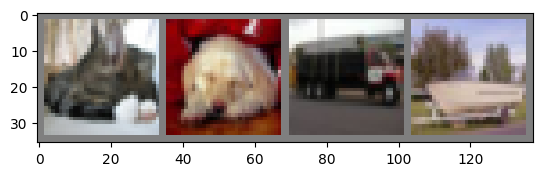

cat   dog   truck ship 


In [7]:
# Functions to show an image
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Show images
imshow(torchvision.utils.make_grid(images))
# Print labels
print(' '.join(f'{trainset.classes[labels[j]]:5s}' for j in range(4)))

In [8]:
import os
from torchvision import datasets, transforms
from PIL import Image

# Specify the root directory for dataset
dataset_root = './cifar10_sampled'

# Create training and validation directories
train_dir = os.path.join(dataset_root, 'train')
val_dir = os.path.join(dataset_root, 'val')

# Classes to extract (by label names in CIFAR-10)
classes = ['cat', 'dog']

# Create directories for each class in train and validation
for c in classes:
    os.makedirs(os.path.join(train_dir, c), exist_ok=True)
    os.makedirs(os.path.join(val_dir, c), exist_ok=True)

# Transformation: Convert to PIL Image (needed to save images)
def to_pil_image(pic):
    denormalize = transforms.Normalize((-1, -1, -1), (2, 2, 2))
    return transforms.ToPILImage()(denormalize(pic)).convert("RGB")

# Load CIFAR-10 dataset
dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())

# Sample and save images
num_samples = 20  # number of samples per class for train
num_val_samples = 5  # number of samples per class for validation

for class_name in classes:
    class_index = dataset.class_to_idx[class_name]
    # Filter images by class
    indices = [i for i, (_, label) in enumerate(dataset) if label == class_index]
    train_indices = indices[:num_samples]
    val_indices = indices[num_samples:num_samples + num_val_samples]
    
    # Save training images
    for idx in train_indices:
        image, label = dataset[idx]
        image = to_pil_image(image)
        image.save(os.path.join(train_dir, class_name, f'{class_name}_{idx}.png'))
    
    # Save validation images
    for idx in val_indices:
        image, label = dataset[idx]
        image = to_pil_image(image)
        image.save(os.path.join(val_dir, class_name, f'{class_name}_{idx}.png'))
